# 02 — Model Training
**Defect Vision System**

Goal: train a small CNN to classify surface images as 'good' or 'defective', tracked with MLflow.

In [1]:
import sys
from pathlib import Path
import os

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))
os.chdir(Path.cwd().parent)
from src.utils.config import load_config
from src.models.train_model import build_model

config = load_config()
model_cfg = config['model']

I0000 00:00:1782679606.788774     711 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782679606.829059     711 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782679608.098496     711 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load train/val image datasets
Using `tf.keras.utils.image_dataset_from_directory`, which expects the standard ImageFolder-style structure (`<split>/<class>/*.png`) produced by notebook 01.

In [2]:
processed_dir = Path(config['data']['processed_dir'])
target_size = tuple(model_cfg['target_size'])

train_ds = keras.utils.image_dataset_from_directory(
    processed_dir / 'train', image_size=target_size,
    batch_size=model_cfg['batch_size'], label_mode='int', shuffle=True,
    seed=model_cfg['random_state'],
)
val_ds = keras.utils.image_dataset_from_directory(
    processed_dir / 'val', image_size=target_size,
    batch_size=model_cfg['batch_size'], label_mode='int', shuffle=False,
)
class_names = train_ds.class_names
print('Classes:', class_names)

Found 1680 files belonging to 2 classes.


Found 360 files belonging to 2 classes.


Classes: ['defective', 'good']


## Look at a batch
Quick visual confirmation that the loader is reading images and labels correctly.

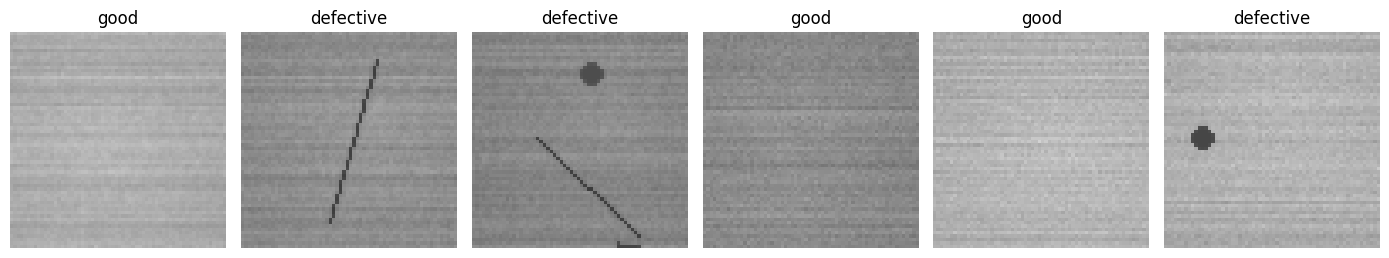

In [3]:
images, labels = next(iter(train_ds))
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i in range(6):
    axes[i].imshow(images[i].numpy().astype('uint8'))
    axes[i].set_title(class_names[labels[i].numpy()])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Build the CNN
A small 3-block convolutional network. Note the final `Dense` (logits) layer is kept separate from the `Activation('softmax')` layer — this matters later for Grad-CAM, since backpropagating from saturated softmax probabilities produces near-zero gradients once the model is confident.

In [4]:
input_shape = target_size + (3,)
model = build_model(input_shape, num_classes=len(class_names),
                    learning_rate=model_cfg['learning_rate'])
model.summary()

Model: "defect_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Activation)        │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,922 (1.09 MB)

 Trainable params: 285,922 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## Train
Early stopping on validation accuracy prevents overfitting and keeps the best weights.

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=model_cfg['epochs'], callbacks=[early_stop], verbose=2,
)

Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 - 4s - 83ms/step - accuracy: 0.6018 - loss: 0.6410 - val_accuracy: 0.9083 - val_loss: 0.3148


Epoch 2/12


53/53 - 5s - 86ms/step - accuracy: 0.9339 - loss: 0.2032 - val_accuracy: 0.9528 - val_loss: 0.1261


...

53/53 - 2s - 47ms/step - accuracy: 0.9899 - loss: 0.0530 - val_accuracy: 0.9917 - val_loss: 0.0397


Epoch 6/12


53/53 - 3s - 48ms/step - accuracy: 0.9845 - loss: 0.0605 - val_accuracy: 0.9861 - val_loss: 0.0584


Epoch 7/12


53/53 - 3s - 50ms/step - accuracy: 0.9917 - loss: 0.0481 - val_accuracy: 0.9861 - val_loss: 0.0479


## Training curves

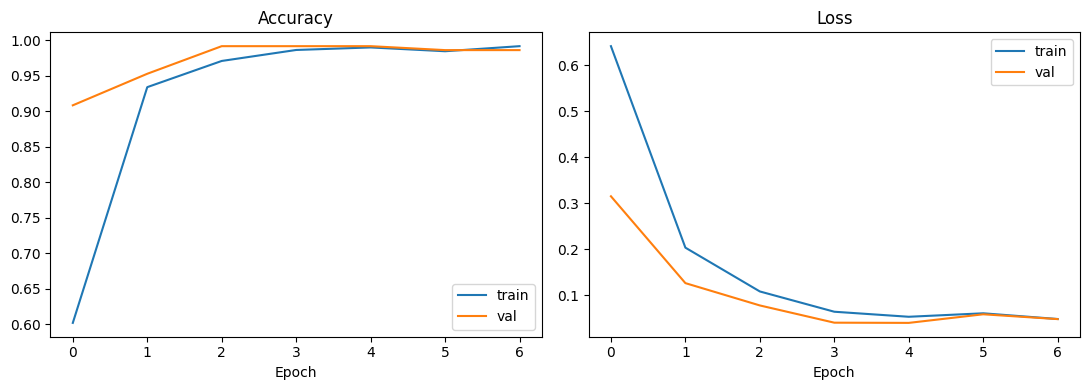

Best validation accuracy: 0.9917


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

## Save the model + class names
This is what `03_gradcam_explainability.ipynb` and `04_evaluation.ipynb` will load.

In [7]:
import json

saved_model_path = Path(model_cfg['saved_model_path'])
saved_model_path.parent.mkdir(parents=True, exist_ok=True)
model.save(saved_model_path)

class_names_path = Path(model_cfg['class_names_path'])
class_names_path.parent.mkdir(parents=True, exist_ok=True)
with open(class_names_path, 'w') as f:
    json.dump(class_names, f)

print(f'Saved -> {saved_model_path}')

Saved -> models/saved_models/defect_cnn.keras
